In [3]:
##### Insights
##### Importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
import folium
import os
import re

##### Data Path
datos_path = os.path.join(
    os.getcwd(),
    'Datos',
    'Cleaned'
)

##### File names
nom_1 = 'visitantes_internacionales.csv'
nom_2 = 'visitantes_sitios_turisticos.csv'
nom_3 = 'inventario_recursos_turisticos.csv'

##### Hyperparams
ANCH = 8
ALT = 5
WIDTH = 0.13


### Insights de Datos 1

In [4]:
##### Inicializando Datos
#### Cargando
df_1 = pd.read_csv(f'{datos_path}/{nom_1}')

#### Eliminando columnas no necesarias
df_1 = df_1.drop(columns=['FECHA_CORTE', 'MES', 'TIPO_VISITANTE'])

#### Separando variables
### Cuantitativo
    # Solo hay uno: NUMERO_VISITANTES
cuant_vars_1 = ['NUMERO_VISITANTES']
### Cualitativo
cual_vars_1 = list(set(df_1.columns)- set(cuant_vars_1))

#### Cambiando AIJC abbreviacion
tmp = df_1[df_1['OCM']=='AEROPUERTO INTERNACIONAL JORGE CHÁVEZ'].index
df_1.loc[tmp, 'OCM'] = 'AIJCH'
del tmp

#### Resumen
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 199584 entries, 0 to 199583
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ANIO               199584 non-null  int64
 1   ID_MES             199584 non-null  int64
 2   ID_PAIS            199584 non-null  int64
 3   PAIS               199584 non-null  str  
 4   ID_CONTINENTE      199584 non-null  int64
 5   CONTINENTE         199584 non-null  str  
 6   ID_OCM             199584 non-null  int64
 7   OCM                199584 non-null  str  
 8   DEPARTAMENTO_OCM   199584 non-null  str  
 9   NUMERO_VISITANTES  199584 non-null  int64
dtypes: int64(6), str(4)
memory usage: 15.2 MB


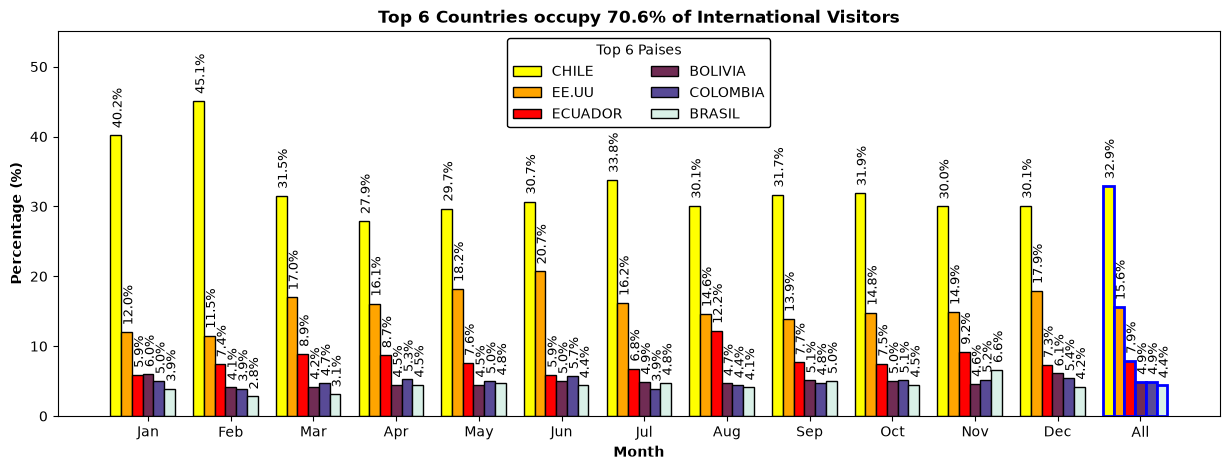

In [5]:
##### Analisis: Pais de origen de visitantes internacionales
#### Seleccionando datos
### Mes por Mes
df_pmn = df_1.groupby(by=['PAIS', 'ID_MES'], as_index=False)\
    ['NUMERO_VISITANTES'].agg('mean')
# display(df_pmn)
### Haciendo fila de todos los meses (pero viendo el promedio del pais)
df_todos = df_1.groupby(by='PAIS', as_index=False)\
    ['NUMERO_VISITANTES'].agg('mean')
df_todos['ID_MES'] = [13]* df_todos.shape[0]
# df_todos
### Uniendo ambos DFs
df_pmtn = pd.concat(
    [df_pmn, df_todos],
    axis=0,
    ignore_index=True,
)

#### Haciendo columna de porcentaje
df_pmtn['PORCENTAJE'] = (
    (
        df_pmtn['NUMERO_VISITANTES'] / \
        df_pmtn.groupby(by='ID_MES')['NUMERO_VISITANTES'].transform('sum')
    ) * 100
).round(1)


#### Esocjiendo top 10 paises con mas alto promedio de en todos meses
top_X = 6
top_X_paises = df_todos\
    .sort_values(by='NUMERO_VISITANTES', ascending=False)\
    ['PAIS'][:top_X]\
    .values.tolist()
paises = ['Chile', 'USA', 'Ecuador', 'Colombia', 'Brazil']
######################################
    # Visual #
#### Creando visual
### Setup
colores = ["#ffff00", "#ffa500", "#ff0000", "#702c54", "#584A96",\
        '#D9F0E7', '#A8DED6', '#78C7C9', '#6FA0C8', '#7E77B8',\
        '#24344A', '#445E89', '#6C8AC9', '#8FAAD6', '#B6D1DB',\
        '#14142e', '#74260a', '#be6f37', '#eeb77d', '#f7d8ab',\
        '#ffb74d', '#ff7043', '#8d6e63', '#fbe9e7', '#3e2723',\
        '#d6e6f2', '#4a90e2', '#7daec8', '#b0bec5', '#d8bfe8', \
        "#a3c1da", "#5b9bd5", "#0e4c92", "#f0f4f8", "#1c1c1c"]
meses = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',\
         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'All']
x = np.arange(len(meses))
centro = list(range(-1*int(len(top_X_paises)/2),int(len(top_X_paises)/2),1))
bars = []
### Grafica
fig, ax = plt.subplots(figsize=(ANCH + 7, ALT))
for i in range(len(top_X_paises)):
    # edgec = 'yellow' if i==len(top_X_paises)-1 else 'black'
    bars.append(ax.bar(
        x + centro[i]*WIDTH,
        df_pmtn[df_pmtn['PAIS']==top_X_paises[i]]\
            ['PORCENTAJE'].values,
        label=top_X_paises[i],
        width=WIDTH,
        color = colores[i],
        edgecolor='black',
        align='center'
    ))
### Agregando texto a barras
## Formula
def agregar_etiquetas(barras):
    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width()/2 + 0.03,  # posición X centrada
            altura+1,                               # posición Y en la cima de la barra
            f'{altura}%',                          # texto
            ha='center', va='bottom', fontsize=9,  # alineación y estilo
            rotation=90,
        )
for bar in bars:
    agregar_etiquetas(bar)  # Asignar Texto
    bar[-1].set_edgecolor('blue')   # Cambiando color de ultimas barras
    bar[-1].set_linewidth(2)
    
### COnfiguraciones finales
ax.set_xticks(x)
ax.set_xticklabels(meses)
ax.set_xlabel('Month', fontweight='bold')
ax.set_ylim(0, max(df_pmtn['PORCENTAJE'])+10)
ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.legend(
    ncol = 2, 
    loc='upper center', 
    title=f'Top {top_X} Paises', 
    edgecolor='black',
    framealpha=1.0
)
ax.set_title("Top 6 Countries occupy 70.6% of International Visitors",
             fontweight='bold')
plt.show()



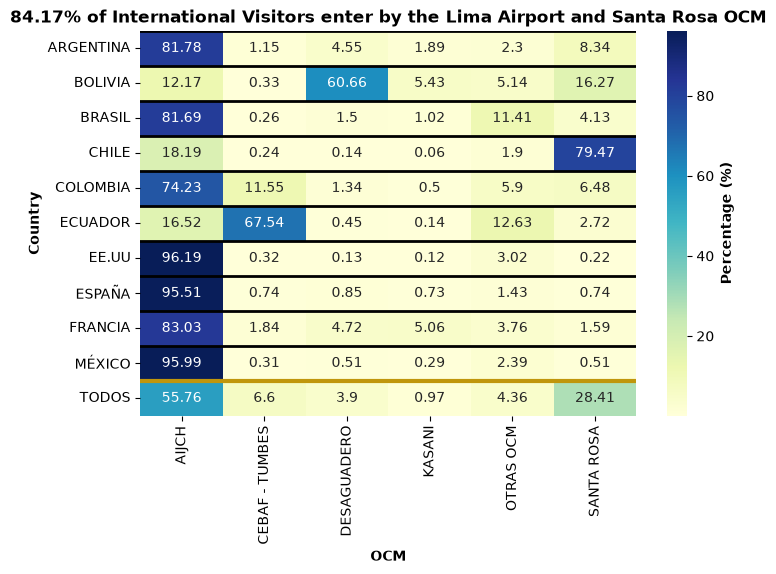

In [6]:
##### Analisis: OCM de entrada entre los visitantes internacionales
#### SEleccionando datos
df_pon = df_1.groupby(by=['PAIS', 'OCM'], as_index=False)\
    ['NUMERO_VISITANTES'].sum()
# display(df_pon)

#### Top 10 paises
top_X = 10
top_X_paises = df_pon.groupby('PAIS', as_index=False)\
    ['NUMERO_VISITANTES'].sum()\
    .sort_values(by='NUMERO_VISITANTES', ascending=False)\
    ['PAIS'].values.tolist()[:top_X]
# print(top_X_paises)

#### Finalizando datos
### Filtracion de datos con top x
df_pon_topX = df_pon[df_pon['PAIS'].isin(top_X_paises)]
# display(df_pon_topX)
### Creando fila de "TODOS" para acompanar a los top X
df_todos = df_1.groupby(by='OCM', as_index=False)\
    ['NUMERO_VISITANTES'].sum()
df_todos['PAIS'] = ['TODOS']*df_todos.shape[0]
# display(df_todos)
### Concatenacion
df_pont = pd.concat([df_pon_topX, df_todos], axis=0, ignore_index=True)
# display(df_pont)


#### Creando porcentaje
df_pont['PORCENTAJE'] = (
    (
        df_pont['NUMERO_VISITANTES']/\
        df_pont.groupby(by='PAIS')['NUMERO_VISITANTES'].transform('sum')
    ) * 100
).round(2)


#############################
    # Visual #
#### Creando datos para el heatmap
### Pivot table del DF
heatmap_data= df_pont\
    .pivot_table(
        index='PAIS',
        columns='OCM',
        values='PORCENTAJE'
    )

#### Creando el heatmap mismo
fig, ax = plt.subplots(figsize=(ANCH, ALT))
ax = sns.heatmap(
    heatmap_data, 
    annot=True, 
    # robust=True,
    cmap='YlGnBu',
    fmt='0',
    linewidths=0,
    linecolor='black',
    cbar=True,
)

#### Agregando lineas horizontales
n_rows = df_pont['PAIS'].unique().shape[0]
for y in range(n_rows):
    ax.axhline(y, color='black', lw=2)  # Adjust color and thickness
    if y == (n_rows-1):
        ax.axhline(y, color="#c0960cff", lw=3)

#### COnfiguraciones de heatmap
ax.set_title('84.17% of International Visitors enter by the Lima Airport and Santa Rosa OCM', fontweight='bold')
ax.set_ylabel('Country', fontweight='bold')
ax.set_xlabel('OCM', fontweight='bold')
ax.collections[0].colorbar.set_label('Percentage (%)', fontweight='bold')



### Insights Datos 2

In [7]:
##### Inicializando Datos
#### Cargando
df_2 = pd.read_csv(f'{datos_path}/{nom_2}')

#### Eliminando columnas no necesarias
df_2 = df_2.drop(columns=['ï»¿FECHA_CORTE'])

#### Filtracion de filas
df_2 = df_2[df_2['TIPO_VISITANTE'] == 'EXTRANJERO']

#### Borrando columna no necesaria
df_2 = df_2.drop(columns=['TIPO_VISITANTE'])


#### Separando variables
### Cuantitativo
    # Solo hay uno: NUMERO_VISITANTES
cuant_vars_2 = ['NUMERO_VISITANTES']
### Cualitativo
cual_vars_2 = list(set(df_2.columns)- set(cuant_vars_2))

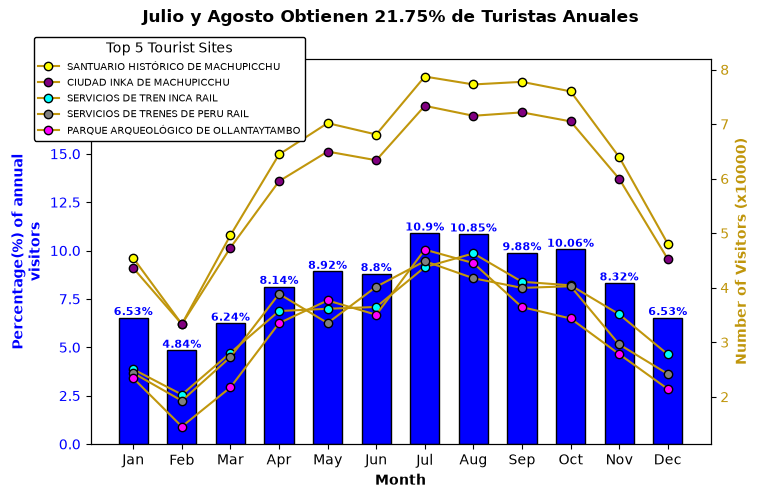

In [ ]:
##### Line graph por mes
##### Datos 1: Linegraph de sitio turistico mas populares
#### Seleccion de datos
df_msn = df_2.groupby(by=['ID_MES','SITIO_TURISTICO'], as_index=False)\
    ['NUMERO_VISITANTES'].mean()
# display(df_msn)

#### Seleccion de top X sitios
top_X = 5
top_X_sitios = df_msn.groupby('SITIO_TURISTICO', as_index=False)\
    ['NUMERO_VISITANTES'].mean()\
    .sort_values(by='NUMERO_VISITANTES', ascending = False)\
    ['SITIO_TURISTICO'][:top_X]\
    .values.tolist()



##### Datos 2: bargraph de 'PORCENTAJE' por 'ID_MES'
#### Seleccion de datos
df_mn = df_2.groupby(by='ID_MES', as_index=False)\
    ['NUMERO_VISITANTES'].mean()
# display(df_mn)

#### Haciendo los porcentajes
df_mn['PORCENTAJE'] = (
    (
        df_mn['NUMERO_VISITANTES']/ \
        df_mn['NUMERO_VISITANTES'].sum()
    ) * 100
).round(2)
# display(df_mn)


###########################
    # Visual #
##### Creando doble grafica
meses_nom = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',\
         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(len(meses_nom))
fig, ax1 = plt.subplots(figsize=(ANCH, ALT))
colores = ["yellow", "purple", "cyan", "grey", "magenta", \
           "red", "black", "green", "orange", "blue"]

#### Bargraph
barras = ax1.bar(
    x,
    df_mn['PORCENTAJE'],
    label = 'Porcentaje',
    color="blue",
    edgecolor='black',
    width = 0.6
)

### Agregando valores textuales
ax1.bar_label(
    barras, 
    labels=[f'{v}%' for v in df_mn['PORCENTAJE']], 
    label_type='edge', 
    fontweight='bold',
    color='blue',
    fontsize=8
)

#### Grafico de linea
exp = 10000
ax2 = ax1.twinx()
for i in range(len(top_X_sitios)):
    ax2.plot(
        x,
        df_msn[df_msn['SITIO_TURISTICO']==top_X_sitios[i]]['NUMERO_VISITANTES']/exp,
        label = top_X_sitios[i],
        # color = colores[i],
        color = "#c0960cff",
        marker='o',
        # markerfacecolor="#9f09da",
        markerfacecolor = colores[i],
        markeredgecolor='black'
    )


#### Configuracion finales
### Bargraph
ax1.set_ylim(0, max(df_mn['PORCENTAJE'])+ 9)
ax1.set_ylabel('Percentage(%) of annual\nvisitors', color="blue", fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Month', fontweight='bold')
## Line graph
ax2.set_ylabel(f'Number of Visitors (x{exp})', color="#c0960cff", fontweight='bold')
ax2.tick_params(axis='y', labelcolor="#c0960cff")
## General
fig.suptitle('July and August obtrain 21.75% of Annual Tourists', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(meses_nom)
ax2.legend(
    bbox_to_anchor =(-0.1, 1.07), 
    fontsize=7.5, 
    title=f'Top {top_X} Tourist Sites',
    loc='upper left',
    edgecolor='black', 
    framealpha=1.0
)



### Insights Datos 3

In [9]:
##### Inicializando Datos
#### Cargando
df_3 = pd.read_csv(f'{datos_path}/{nom_3}')

#### Eliminando columnas no necesarias
df_3 = df_3.drop(columns=[
    'URL', 'FECHA_DE_CORTE', 'TIPO', 'OBSERVACION'
])


#### Separando variables
### Cuantitativo
cuant_vars_3 = df_3._get_numeric_data().columns.values
### Cualitativo
cual_vars_3 = list(set(df_3.columns)- set(cuant_vars_3))


#### Cambiando valor ingreso de Machu Picchu
    # No se capturo pq esta en USD, no S/
idx_MP = df_3[df_3['NOMBRE DEL RECURSO'] == 'Parque Arqueológico Nacional De Machu Picchu'].index
df_3.loc[idx_MP, 'INGRESO'] = 117.3
display(df_3.iloc[idx_MP])  # Verificacion

#### Resumen
df_3.info()

,DEPARTAMENTO,PROVINCIA,DISTRITO,CODIGO DEL RECURSO,NOMBRE DEL RECURSO,CATEGORIA,TIPO_CATEGORIA,SUBTIPO_CATEGORIA,LONGITUD,LATITUD,INGRESO
414,Cusco,Urubamba,MACHUPICCHU,917,Parque Arqueológico Nacional De Machu Picchu,2. MANIFESTACIONES CULTURALES,Sitios Arqueológicos,Parques arqueológicos,-72.545249,-13.162864,117.3


<class 'pandas.DataFrame'>
RangeIndex: 4539 entries, 0 to 4538
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DEPARTAMENTO        4539 non-null   str    
 1   PROVINCIA           4539 non-null   str    
 2   DISTRITO            4539 non-null   str    
 3   CODIGO DEL RECURSO  4539 non-null   int64  
 4   NOMBRE DEL RECURSO  4539 non-null   str    
 5   CATEGORIA           4539 non-null   str    
 6   TIPO_CATEGORIA      4539 non-null   str    
 7   SUBTIPO_CATEGORIA   4539 non-null   str    
 8   LONGITUD            4539 non-null   float64
 9   LATITUD             4539 non-null   float64
 10  INGRESO             4539 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 390.2 KB


In [10]:
###### Analisis: Sitios gratis alrededor de MP
##### Encontrar distancia de todos los otros sitios a MP
#### Seleccionando coordenadas de MP
MP_lat = df_3[df_3['NOMBRE DEL RECURSO'] == 'Parque Arqueológico Nacional De Machu Picchu']\
        ['LATITUD'].values.tolist()[0]
MP_lon = df_3[df_3['NOMBRE DEL RECURSO'] == 'Parque Arqueológico Nacional De Machu Picchu']\
        ['LONGITUD'].values.tolist()[0]
print(MP_lon, MP_lat)

#### Creando formula para medir distancia de dos coordinadas
def distancia(fila, lat_sitio, lon_sitio):
    R = 6371.0  # 6371 kilometros por radian de Tierra

    # Configuraciones
    lat1 = fila['LATITUD']
    lon1 = fila['LONGITUD']
    lat2 = lat_sitio
    lon2 = lon_sitio
    
    # Convertir grados a radianes
    lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
    lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)

    # Diferencias
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    # Fórmula de Haversine
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))  # Radian distancia (de la tierra) entre ambos puntos

    return R * c 

#### Creando distancia de cada registro/sitio a MP
ds_dist_MP = df_3.apply(distancia, axis=1, args=[MP_lat, MP_lon])
ds_dist_MP.name = 'DISTANCIA_MP'
# display(df_dist_MP)

#### Uniendo datos
df_con_dist = pd.concat([df_3, ds_dist_MP], axis=1)\
    .sort_values(by='DISTANCIA_MP', ascending=True)
# display(df_con_dist)

###################################
    # Visual #
#### Creando geografico
### Setup
mapa = folium.Map(
    location=[MP_lat, MP_lon],
    zoom_start=13
)
folium.Marker(
    location=[MP_lat, MP_lon],
    popup="Machu Picchu",
    icon=folium.Icon(icon="star", prefix="fa", color="blue")
).add_to(mapa)
radios = [5,10,15,20,25]
colores = ["#ffff00", "#ffa500", "#ff0000", "#702c54", "#584A96"]
cantidades = []
### Creacion de Concentric circulos
for i, radio in enumerate(radios[::-1]):
    cantidad = df_con_dist[
        (df_con_dist['DISTANCIA_MP'] <= radio) & \
        (df_con_dist['INGRESO'] == 0)
    ].shape[0]
    cantidades.append(cantidad)
    folium.Circle(
        location=(MP_lat, MP_lon),
        radius=radio*1000,  #Relacion entre metros y kms
        color=colores[i],
        fill=True,
        fill_opacity=0.2,
        tooltip=f'{cantidad}',  #Solo 
    ).add_to(mapa)

### Agregando estrellas en los sitios seleccionados
df_sitios = df_con_dist[
        (df_con_dist['DISTANCIA_MP'] <= 25) & \
        (df_con_dist['INGRESO'] == 0)
    ]
display(df_sitios)

for idx, fila in df_sitios.iterrows():
    folium.Marker(
        location=[fila['LATITUD'], fila['LONGITUD']],
        popup=f"{fila['NOMBRE DEL RECURSO']}",
        icon=folium.Icon(icon="star", prefix="fa", color="orange")
    ).add_to(mapa)


# HTML y CSS para la leyenda
legend_html = f"""
<div style="
    position: fixed; 
    bottom: 30px; left: 30px; width: 180px; 
    background-color: white; 
    border:2px solid grey; 
    z-index:9999; 
    font-size:14px;
    padding: 10px;
">
<b>Legend</b><br>
<i style="background:#584A96; opacity:0.5; border-radius:50%; width:12px; height:12px; display:inline-block;"></i> 5 km - {cantidades[4]} free entry sites<br>
<i style="background:#702c54; opacity:0.5; border-radius:50%; width:12px; height:12px; display:inline-block;"></i> 10 km - {cantidades[3]} free entry sites<br>
<i style="background:#ff0000; opacity:0.5; border-radius:50%; width:12px; height:12px; display:inline-block;"></i> 15 km - {cantidades[2]} free entry sites<br>
<i style="background:#ffa500; opacity:0.5; border-radius:50%; width:12px; height:12px; display:inline-block;"></i> 20 km - {cantidades[1]} free entry sites<br>
<i style="background:#ffff00; opacity:0.5; border-radius:50%; width:12px; height:12px; display:inline-block;"></i> 25 km - {cantidades[0]} free entry sites
</div>
"""

# Agregar leyenda al mapa
mapa.get_root().html.add_child(folium.Element(legend_html))

### Guardando
mapa.save('MP.html')

-72.54524856805801 -13.162864352674784


,DEPARTAMENTO,PROVINCIA,DISTRITO,CODIGO DEL RECURSO,NOMBRE DEL RECURSO,CATEGORIA,TIPO_CATEGORIA,SUBTIPO_CATEGORIA,LONGITUD,LATITUD,INGRESO,DISTANCIA_MP
2841,Cusco,Urubamba,MACHUPICCHU,11012,Montaña De Putucusi,1. SITIOS NATURALES,a. Montañas,Cerros,-72.536068,-13.154594,0.0,1.354134
4336,Cusco,Urubamba,MACHUPICCHU,14272,Templo De La Virgen Del Carmen De Machupicchu,2. MANIFESTACIONES CULTURALES,Arquitectura y Espacios Urbanos,Templo,-72.525537,-13.154210,0.0,2.341201
4335,Cusco,Urubamba,MACHUPICCHU,14240,Mirador De Tunki,1. SITIOS NATURALES,ñ. Zonas paisajísticas,Otros,-72.524436,-13.153592,0.0,2.478152
4337,Cusco,Urubamba,MACHUPICCHU,14277,Crónicas De Piedra,"4. REALIZACIONES TÉCNICAS, CIENTÍFICAS Y ARTÍS...",Otros,Otros,-72.523998,-13.153604,0.0,2.520803
1124,Cusco,Urubamba,MACHUPICCHU,3674,Catarata De Mandor,1. SITIOS NATURALES,j. Caídas de agua,Cataratas,-72.535300,-13.141985,0.0,2.559375
2843,Cusco,Urubamba,MACHUPICCHU,14232,Cascada De Aguas Calientes,1. SITIOS NATURALES,j. Caídas de agua,Cascadas,-72.521330,-13.149250,0.0,2.999841
2745,Cusco,La Convencion,SANTA TERESA,11848,Camino Inka Jungle Tramo Santa Maria La Antigu...,2. MANIFESTACIONES CULTURALES,Arquitectura y Espacios Urbanos,Fortalezas,-72.594200,-13.130300,0.0,6.419253
2739,Cusco,La Convencion,SANTA TERESA,11500,Cataratas De Chaquiorco,1. SITIOS NATURALES,j. Caídas de agua,Cataratas,-72.598611,-13.129722,0.0,6.853313
3663,Cusco,La Convencion,HUAYOPATA,12464,Mirador Apu Yanantin - Machupicchu,1. SITIOS NATURALES,ñ. Zonas paisajísticas,Miradores naturales,-72.507361,-13.088629,0.0,9.218005
1904,Cusco,La Convencion,HUAYOPATA,6916,Sitio Arqueologico De Inca Carcel,2. MANIFESTACIONES CULTURALES,Sitios Arqueológicos,Templos,-72.608974,-13.061142,0.0,13.250114
